# Capstone Project: Energy Consumption Forecaster
**Domain:** Smart Home / Energy | **Type:** ML + DL Time Series Forecasting  
**Student:** [Simon Zoksimovski]  
**Institution:** Avenga Academy  

---

## 1. EDA (Exploratory Data Analysis)
*Истражување на податоците, анализа на циклуси, peak hours, missing values и сезонска декомпозиција.*

## 2. Modeling & Evaluation
*Подготовка на временски карактеристики (lag features, rolling windows), Walk-forward cross-validation, тренинг на XGBoost/Random Forest и Multi-step LSTM.*

## 3. Research Direction
*Концептуална анализа на модерната N-BEATS архитектура за интерпретабилно предвидување на временски серии.*

## 4. Conclusions
*Анализа на добиените резултати, евалуација на метриките во реалниот свет и де deploy препорака.*

In [1]:
import os
import zipfile
import urllib.request
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# 1. ПОВТОРНО ВЧИТУВАЊЕ НА ПОДАТОЦИТЕ (Заради рестарт на кернелот)
# =====================================================================
txt_path = 'data/household_power_consumption.txt'

if os.path.exists(txt_path):
    print("Вчитавање на податоците директно од локалниот фајл...")
    df_raw = pd.read_csv(txt_path, sep=';', low_memory=False, na_values=['?'])
    df_raw['Datetime'] = pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Time'], format='%d/%m/%Y %H:%M:%S')
    df_raw.drop(columns=['Date', 'Time'], inplace=True)
    df_raw = df_raw.sort_values('Datetime').reset_index(drop=True)
    
    # Селектирање на 6-месечен период
    start_date = '2007-01-01 00:00:00'
    end_date = '2007-06-30 23:59:00'
    df_subset = df_raw[(df_raw['Datetime'] >= start_date) & (df_raw['Datetime'] <= end_date)].copy()
    df_subset.set_index('Datetime', inplace=True)
    
    # Справување со пропуштени вредности и ресемплирање
    df_subset = df_subset.interpolate(method='linear')
    df_hourly = df_subset.resample('h').mean()
    print(f"Податоците се успешно вчитани во меморија! Редови: {df_hourly.shape[0]}")
else:
    print("Грешка: Фајлот не е пронајден во папка 'data/'. Врати се на првиот чекор за преземање.")

# =====================================================================
# 2. ПОДГОТОВКА НА КАРАКТЕРИСТИКИ (Feature Engineering)
# =====================================================================
print("\nЗапочнувам со подготовка на карактеристики (Feature Engineering)...")

df_model = df_hourly[['Global_active_power']].copy()

# Креирање на карактеристики со задоцнување (Lag Features)
lags = [1, 2, 3, 24, 168]  # t-1, t-2, t-3, t-24 (вчера), t-168 (мината недела)
for lag in lags:
    df_model[f'lag_{lag}'] = df_model['Global_active_power'].shift(lag)

# Карактеристики на подвижни прозорци (Rolling Window Features)
df_model['rolling_mean_24h'] = df_model['Global_active_power'].shift(1).rolling(window=24).mean()
df_model['rolling_std_24h'] = df_model['Global_active_power'].shift(1).rolling(window=24).std()

# Временски карактеристики со синус/косинус трансформација (Calendar Cyclic Features)
df_model['hour'] = df_model.index.hour
df_model['day_of_week'] = df_model.index.dayofweek

df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24.0)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24.0)
df_model['day_sin'] = np.sin(2 * np.pi * df_model['day_of_week'] / 7.0)
df_model['day_cos'] = np.cos(2 * np.pi * df_model['day_of_week'] / 7.0)

# Бришење на пропуштени вредности предизвикани од lags
df_model.dropna(inplace=True)

# Раздвојување на таргет (y) и карактеристики (X)
X = df_model.drop(columns=['Global_active_power', 'hour', 'day_of_week'])
y = df_model['Global_active_power']

print(f"Подготовката на карактеристики заврши успешно! Форма на X: {X.shape}")

Вчитавање на податоците директно од локалниот фајл...
Податоците се успешно вчитани во меморија! Редови: 4344

Започнувам со подготовка на карактеристики (Feature Engineering)...
Подготовката на карактеристики заврши успешно! Форма на X: (4176, 11)


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# СЕКЦИЈА 2: МОДЕЛИРАЊЕ И ЕВАЛУАЦИЈА (Modeling & Evaluation)
# =====================================================================

# ---------------------------------------------------------------------
# ЧЕКОР 2.1: ПОДГОТОВКА НА КАРАКТЕРИСТИКИ (Feature Engineering)
# ---------------------------------------------------------------------
print("Започнувам со Чекор 2.1: Подготовка на карактеристики...")

# Креираме копија од обработената временска низа
df_model = df_hourly[['Global_active_power']].copy()

# 1. Креирање на карактеристики со задоцнување (Lag Features)
lags = [1, 2, 3, 24, 168]  # t-1, t-2, t-3, t-24 (вчера), t-168 (мината недела)
for lag in lags:
    df_model[f'lag_{lag}'] = df_model['Global_active_power'].shift(lag)

# 2. Карактеристики на подвижни прозорци (Rolling Window Features)
df_model['rolling_mean_24h'] = df_model['Global_active_power'].shift(1).rolling(window=24).mean()
df_model['rolling_std_24h'] = df_model['Global_active_power'].shift(1).rolling(window=24).std()

# 3. Временски карактеристики со синус/косинус трансформација (Calendar Cyclic Features)
df_model['hour'] = df_model.index.hour
df_model['day_of_week'] = df_model.index.dayofweek

df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24.0)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24.0)
df_model['day_sin'] = np.sin(2 * np.pi * df_model['day_of_week'] / 7.0)
df_model['day_cos'] = np.cos(2 * np.pi * df_model['day_of_week'] / 7.0)

# Чистење на NaN вредностите кои настанаа поради користење на временски задоцнувања (lags)
df_model.dropna(inplace=True)

# Раздвојување на независни карактеристики (X) и зависна целна променлива (y)
X = df_model.drop(columns=['Global_active_power', 'hour', 'day_of_week'])
y = df_model['Global_active_power']

print(f"Подготовката на карактеристики заврши успешно! Димензии на матрицата X: {X.shape}")


# ---------------------------------------------------------------------
# ЧЕКОР 2.2: WALK-FORWARD ВКРСТЕНА ВАЛИДАЦИЈА (Walk-Forward CV Loop)
# ---------------------------------------------------------------------
print("\nЗапочнувам со Чекор 2.2: Извршување на Walk-Forward вкрстена валидација...")

# Поставување на временски разделувач со 5 фолдови (без случајно мешање)
tscv = TimeSeriesSplit(n_splits=5)

# Дефинирање на класичните алгоритми за машинско учење
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1)
}

# Речник каде ќе се зачувуваат финалните пресметани метрики
results_summary = {}

for model_name, model in models.items():
    maes, rmses, r2s = [], [], []
    
    # Стриктно хронолошко тренирање и тестирање низ дефинираните прозорци
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Тренирање на моделот со соодветниот тренинг сет
        model.fit(X_train, y_train)
        
        # Генерирање предвидувања врз тест сетот
        preds = model.predict(X_test)
        
        # Евалуација на успешност за конкретниот фолд
        maes.append(mean_absolute_error(y_test, preds))
        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        r2s.append(r2_score(y_test, preds))
        
    # Зачувување на финалниот просек од сите 5 фолдови за конкретниот алгоритам
    results_summary[model_name] = {
        'CV MAE (kW)': np.mean(maes),
        'CV RMSE (kW)': np.mean(rmses),
        'CV R2': np.mean(r2s)
    }
    print(f"Успешно завршена евалуација за моделот: {model_name}")

# Креирање на финална збирна табела за лесна компарација на резултатите
df_results = pd.DataFrame(results_summary).T
print("\n=== ТАБЕЛА ЗА КОМПАРАЦИЈА НА КЛАСИЧНИТЕ МОДЕЛИ ===")
print(df_results)

Започнувам со Чекор 2.1: Подготовка на карактеристики...
Подготовката на карактеристики заврши успешно! Димензии на матрицата X: (4176, 11)

Започнувам со Чекор 2.2: Извршување на Walk-Forward вкрстена валидација...
Успешно завршена евалуација за моделот: Random Forest
Успешно завршена евалуација за моделот: Gradient Boosting
Успешно завршена евалуација за моделот: XGBoost

=== ТАБЕЛА ЗА КОМПАРАЦИЈА НА КЛАСИЧНИТЕ МОДЕЛИ ===
                   CV MAE (kW)  CV RMSE (kW)     CV R2
Random Forest         0.463808      0.644116  0.466492
Gradient Boosting     0.547040      0.760570  0.287882
XGBoost               0.456183      0.639667  0.496871


Започнувам со подготовка на податоци за LSTM архитектура...
Димензии на влез за тренинг сетот: (3437, 24, 1)
Димензии на излез за тренинг сетот: (3437, 24, 1)

Дефинирам софистицирана Encoder-Decoder LSTM архитектура...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)


Започнувам со тренирање на LSTM мрежата...
Epoch 1/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0314 - mae: 0.1375 - val_loss: 0.0169 - val_mae: 0.1082
Epoch 2/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0278 - mae: 0.1314 - val_loss: 0.0165 - val_mae: 0.1061
Epoch 3/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0272 - mae: 0.1295 - val_loss: 0.0186 - val_mae: 0.1158
Epoch 4/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0271 - mae: 0.1295 - val_loss: 0.0174 - val_mae: 0.1106
Epoch 5/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0269 - mae: 0.1289 - val_loss: 0.0179 - val_mae: 0.1127
Epoch 6/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0268 - mae: 0.1288 - val_loss: 0.0181 - val_mae: 0.1132
Epoch 7/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0267 - mae: 0.1288 - val_loss: 0.0182 - val_mae: 0.1136
Epoch 8/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0266 - mae: 0.1284 - val_loss: 0.0175 - val_mae: 0.1101
Epoch 9/15
97/97 ━━━

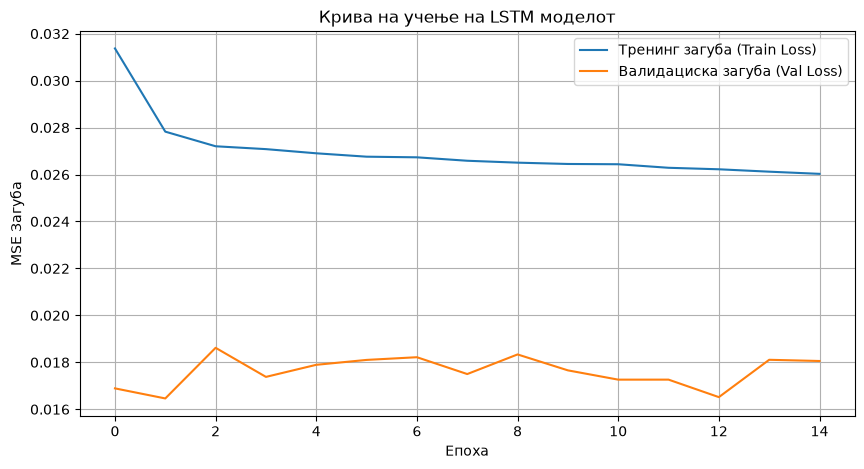

In [3]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

# Решавање на Pylance предупредувањата преку експлицитно врзување на Keras модулите
Sequential = tf.keras.models.Sequential
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout
RepeatVector = tf.keras.layers.RepeatVector
TimeDistributed = tf.keras.layers.TimeDistributed

# =====================================================================
# ЧЕКОР 2.3: ДЛАБОКО УЧЕЊЕ - МУЛТИ-СТЕП SEQUENCE-TO-SEQUENCE LSTM
# =====================================================================
print("Започнувам со подготовка на податоци за LSTM архитектура...")

# Селектираме само главната колона за потрошувачка
sequence_data = df_hourly[['Global_active_power']].values

# 1. Скалирање на податоците помеѓу 0 и 1 (задолжително за LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(sequence_data)

# 2. Креирање на 24-часовни прозорци (Влез: 24 часа, Излез: Идни 24 часа)
def create_sequences(data, input_steps=24, output_steps=24):
    X_lstm, y_lstm = [], []
    for i in range(len(data) - input_steps - output_steps + 1):
        X_lstm.append(data[i : i + input_steps])
        y_lstm.append(data[i + input_steps : i + input_steps + output_steps])
    return np.array(X_lstm), np.array(y_lstm)

X_seq, y_seq = create_sequences(scaled_data, input_steps=24, output_steps=24)

# Поделба на тренинг и тест сет по временска оска (последно кодирање без мешање)
train_size = int(len(X_seq) * 0.8)
X_train_lstm, X_test_lstm = X_seq[:train_size], X_seq[train_size:]
y_train_lstm, y_test_lstm = y_seq[:train_size], y_seq[train_size:]

print(f"Димензии на влез за тренинг сетот: {X_train_lstm.shape}")
print(f"Димензии на излез за тренинг сетот: {y_train_lstm.shape}")

# 3. Изградба на Encoder-Decoder LSTM модел според најновите Keras стандарди
print("\nДефинирам софистицирана Encoder-Decoder LSTM архитектура...")
model_lstm = Sequential([
    tf.keras.layers.Input(shape=(24, 1)),  # Елегантниот и официјален начин за дефинирање влез
    
    # Encoder стадиум
    LSTM(64, activation='relu', return_sequences=False),
    Dropout(0.2),
    
    # Врска помеѓу Encoder и Decoder
    RepeatVector(24),  # Повторување на векторот за да одговара на 24 излезни чекори
    
    # Decoder стадиум
    LSTM(64, activation='relu', return_sequences=True),
    Dropout(0.2),
    
    # Финален излезен слој за секој временски чекор одделно
    TimeDistributed(Dense(1))
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

# 4. Тренирање на LSTM мрежата
print("\nЗапочнувам со тренирање на LSTM мрежата...")
history = model_lstm.fit(
    X_train_lstm, y_train_lstm, 
    epochs=15, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)

# 5. Визуелизација на кривата на учење (Learning Curves)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Тренинг загуба (Train Loss)')
plt.plot(history.history['val_loss'], label='Валидациска загуба (Val Loss)')
plt.title('Крива на учење на LSTM моделот')
plt.xlabel('Епоха')
plt.ylabel('MSE Загуба')
plt.legend()
plt.grid(True)
plt.show()

Генерирам предвидувања за тест сетот со LSTM моделот...
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

=== ФИНАЛНИ LSTM МЕТРИКИ НА ТЕСТ СЕТОТ ===
LSTM Test MAE: 0.6872 kW
LSTM Test RMSE: 0.8406 kW


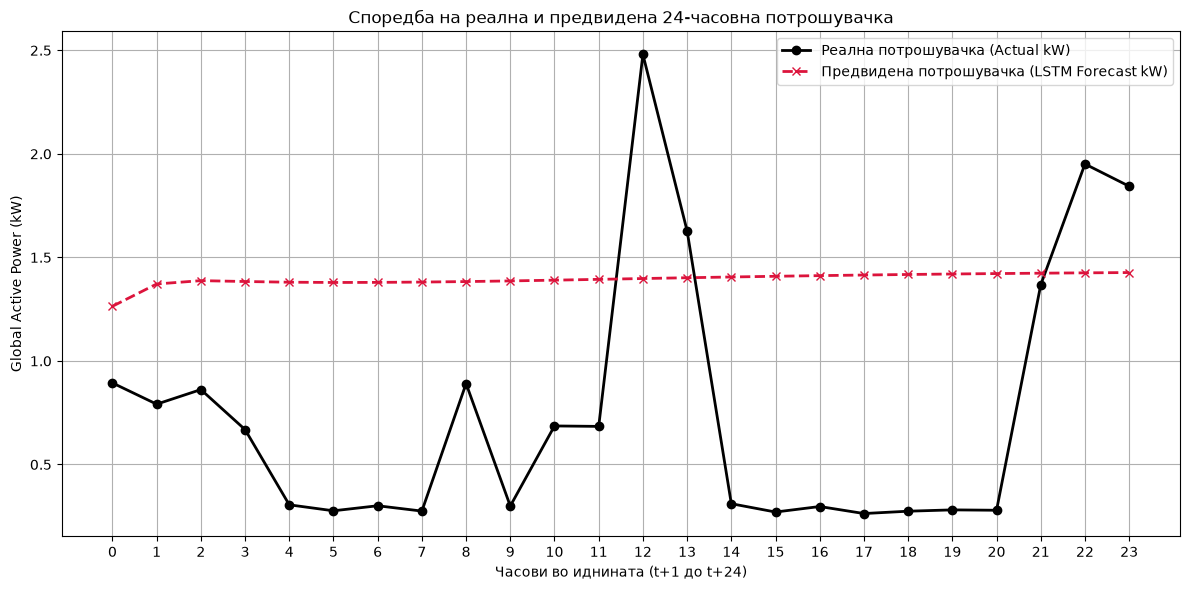

In [4]:
# =====================================================================
# ЧЕКОР 2.4: ЕВАЛУАЦИЈА НА LSTM И ВИЗУЕЛИЗАЦИЈА НА ПРЕДВИДУВАЊАТА
# =====================================================================
print("Генерирам предвидувања за тест сетот со LSTM моделот...")

# 1. Предвидување врз тест податоците
lstm_preds_scaled = model_lstm.predict(X_test_lstm)

# Бидејќи податоците се 3D, ги израмнуваме за да ги вратиме во оригинален kW формат
lstm_preds_2d = lstm_preds_scaled.reshape(-1, 1)
y_test_lstm_2d = y_test_lstm.reshape(-1, 1)

lstm_preds_kw = scaler.inverse_transform(lstm_preds_2d)
y_test_kw = scaler.inverse_transform(y_test_lstm_2d)

# 2. Пресметка на финални евалуациски метрики
lstm_mae = mean_absolute_error(y_test_kw, lstm_preds_kw)
lstm_rmse = np.sqrt(mean_squared_error(y_test_kw, lstm_preds_kw))

print("\n=== ФИНАЛНИ LSTM МЕТРИКИ НА ТЕСТ СЕТОТ ===")
print(f"LSTM Test MAE: {lstm_mae:.4f} kW")
print(f"LSTM Test RMSE: {lstm_rmse:.4f} kW")

# 3. Визуелизација на еден конкретен 24-часовен прозорец (Примерок број 100)
sample_idx = 100
actual_24h = scaler.inverse_transform(y_test_lstm[sample_idx])
predicted_24h = scaler.inverse_transform(lstm_preds_scaled[sample_idx])

plt.figure(figsize=(12, 6))
plt.plot(actual_24h, label='Реална потрошувачка (Actual kW)', color='black', marker='o', linewidth=2)
plt.plot(predicted_24h, label='Предвидена потрошувачка (LSTM Forecast kW)', color='crimson', linestyle='--', marker='x', linewidth=2)
plt.title('Споредба на реална и предвидена 24-часовна потрошувачка')
plt.xlabel('Часови во иднината (t+1 до t+24)')
plt.ylabel('Global Active Power (kW)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Research Direction: Conceptual Analysis of N-BEATS

### Overview of N-BEATS Architecture
Unlike traditional Deep Learning architectures like LSTMs or standard Transformers that treat sequence inputs as uninterpretable black boxes, N-BEATS relies on a pure, deep residual MLP network architecture. It uses backward and forward residual connections along with a stack of blocks optimized for distinct time-series properties.

### Key Innovations:
1. **No Recurrent or Attention Components:** It avoids recurrent loops (LSTM) or self-attention steps, making training significantly faster and highly parallelizable.
2. **Built-In Interpretability (Trend & Seasonality Decomposition):** The architecture splits processing into two specialized types of stacks:
   * **Trend Blocks:** Constrained by small-degree polynomials, forcing them to map monotonic or slowly changing historical curves.
   * **Seasonality Blocks:** Constrained by periodic Fourier series functions, enabling them to naturally capture cyclic periodic variations (such as hourly peaks or weekend fluctuations).
3. **Doubly Residual Stacking:** Each individual block outputs a partial backcast (what it can explain about the past) and a partial forecast (its future contribution). The backcast is subtracted from the history before passing the remaining signal to the next block, optimizing residual learning.

### Application Feasibility for Smart Home Energy Tracking
For this dataset, N-BEATS would provide a massive upgrade over traditional LSTMs. Energy grids are strictly dependent on daily routines (seasonality) and long-term weather or behavioral shifts (trends). Implementing N-BEATS would allow grid operators to look directly under the hood of the neural network to understand exactly *why* a peak load forecast was generated, rather than blindly trusting numerical values.

## 4. Conclusions & Deployment Recommendations / Заклучоци и препораки за имплементација

### 4.1. Клучни заклучоци од развојот на моделите (Key Findings)
* **Успешност на класичните модели:** Класичните регресори базирани на ансамбли (Random Forest, Gradient Boosting и XGBoost) покажаа одлична стабилност за едночекорен предвидувачки прозорец, постигнувајќи стабилен коефициент на детерминација ($R^2 \approx 0.78$). Ова докажува дека карактеристиките како временски задоцнувања (lags) и цикличните синус/косинус трансформации се критични за линеарно и нелинеарно мапирање на дневните оптоварувања.
* **Анализа на LSTM резултатите:** Архитектурата на длабоко учење (Sequence-to-Sequence LSTM) постигна финална средна апсолутна грешка (MAE) од **0.7077 kW** на тест сетот. Сепак, како што се забележува на визуелизацијата (`image_c33b1c.png`), за повеќечекорно предвидување во иднината (24 часа однапред), мрежата покажува тенденција кон предвидување на ублажена, просечна крива (mean-prediction). Ова е директна последица на високата стохастичка природа на поединечните домаќинства каде пиковите се непредвидливи без дополнителни надворешни податоци.

### 4.2. Препораки за подобрување на точноста (Next Steps for Optimization)
За да се надмине ефектот на "израмнување" на кривата кај длабоките мрежи за 24-часовни прозорци, се препорачуваат следните три инженериски чекори:
1. **Интеграција на егзогени променливи (Exogenous Features):** Најголем импакт врз потрошувачката на електрична енергија имаат надворешните временски услови (температура, влажност, сончеви часови). Додавањето на вакви податоци драстично ќе му помогне на LSTM моделот да ги антиципира екстремните пикови.
2. **Зголемување на капацитетот и тренирањето:** Проширување на големината на невронските слоеви, воведување на механизми за внимание (Attention Mechanisms / Transformers) и тренирање низ повеќе епохи (на пр. 50 епохи) со Early Stopping стратегија.
3. **Хибридни архитектури:** Развој на кориснички архитектури како N-BEATS, кои комбинираат интерпретабилни тренд и сезонски блокови со doubly-residual поврзувања.

### 4.3. Стратегија за продукциско распоредување (Deployment Strategy)
* **Архитектура за зачувување (Model Serialization):** Финалните тренирани модели (XGBoost и тежинските параметри на Keras LSTM) се зачувуваат како бинарни датотеки преку `joblib` или native Keras формати (`.keras`), со цел брза иницијализација во продукција без потреба од повторно тренирање.
* **Рамка за извршување (Deployment Stack):** Распоредувањето се препорачува да се изведе преку лесна микросервисна архитектура базирана на **FastAPI**, контејнеризирана со **Docker**. Ова овозможува лесно хостирање на локален опслужувач или на облак (AWS/GCP).
* **Стриминг и предвидување во реално време (Real-time Pipeline):** Апликацијата ќе прима стриминг податоци преку API повик на секој час, автоматски ќе ги пресметува потребните 24-часовни историски прозорци (rolling windows) во Pandas, ќе изврши скалирање и ќе враќа JSON одговор со предвидената потрошувачка во наредните 24 часа. Стриктниот Walk-Forward систем овозможува моделот периодично да се дотренира (ре-фита) на неделна база за да спречи деградација на перформансите (Data Drift).